## 🔧 Section 1: Setup and Imports\n
\n
Install and import all necessary libraries for the project.

In [1]:
# Install required packages (uncomment if needed)
# !pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('✓ All libraries imported successfully')
print(f'TensorFlow version: {tf.__version__}')

✓ All libraries imported successfully
TensorFlow version: 2.19.0


## 📂 Section 2: Data Loading and Inspection\n
\n
**TASK 1:** Load and inspect the time-series data\n
\n
**Note:** Replace the data generation code below with your actual dataset loading code.

In [20]:

from google.colab import drive
drive.mount('/content')
df_raw = pd.read_csv('Productlevel_Sales_Transactions_Dataset_Weekly.csv')


print(f'Dataset Shape: {df_raw.shape}')
print(f'Date Range: {df_raw["Date"].min()} to {df_raw["Date"].max()}')
print(f'Unique SKUs: {df_raw["SKU"].nunique()}')
print(f'\First 10 rows:')
display(df_raw.head(10))
print(f'\Dataset Info:')
df_raw.info()
print(f'\Missing Values: {df_raw.isnull().sum().sum()}')

ValueError: Mountpoint must not already contain files

In [17]:
print(df_raw.columns)

Index(['Scode', 'Pcode', 'Price', 'Wk0', 'Wk1', 'Wk2', 'Wk3', 'Wk4', 'Wk5',
       'Wk6',
       ...
       'Wk96', 'Wk97', 'Wk98', 'Wk99', 'Wk100', 'Wk101', 'Wk102', 'Wk103',
       'Unnamed: 107', '94'],
      dtype='object', length=109)


## 🔄 Section 3: Data Preprocessing\n
\n
**TASK 2:** Convert to time-indexed format\n
**TASK 3:** Aggregate SKU-level sales data weekly\n
**TASK 4:** Handle missing weeks and interpolate

In [3]:


df_indexed = df_raw.copy()
df_indexed['Date'] = pd.to_datetime(df_indexed['Date'])
print('✓ Date column converted to datetime type')



df_indexed_sorted = df_indexed.sort_values('Date').copy()
weekly_data_list = []

for sku in skus:
    sku_data = df_indexed_sorted[df_indexed_sorted['SKU'] == sku].copy()
    sku_data.set_index('Date', inplace=True)
    weekly_agg = sku_data['Sales_Quantity'].resample('W-MON').sum()

    for date, sales in weekly_agg.items():
        weekly_data_list.append({
            'Week_Start': date,
            'SKU': sku,
            'Weekly_Sales': sales
        })

df_weekly = pd.DataFrame(weekly_data_list)
df_weekly = df_weekly.sort_values(['SKU', 'Week_Start']).reset_index(drop=True)

print(f'Weekly Aggregated Data Shape: {df_weekly.shape}')
print(f'Number of weeks: {df_weekly["Week_Start"].nunique()}')
display(df_weekly.head(10))



all_weeks = pd.date_range(start=df_weekly['Week_Start'].min(),
                          end=df_weekly['Week_Start'].max(),
                          freq='W-MON')

complete_data_list = []
for sku in skus:
    for week in all_weeks:
        complete_data_list.append({'Week_Start': week, 'SKU': sku})

df_complete = pd.DataFrame(complete_data_list)
df_weekly_complete = df_complete.merge(df_weekly, on=['Week_Start', 'SKU'], how='left')

df_interpolated = df_weekly_complete.copy()
for sku in skus:
    mask = df_interpolated['SKU'] == sku
    df_interpolated.loc[mask, 'Weekly_Sales'] = df_interpolated.loc[mask, 'Weekly_Sales'].interpolate(
        method='linear', limit_direction='both'
    )

df_final = df_interpolated.copy()
print(f'✓ Missing values interpolated: {df_final["Weekly_Sales"].isnull().sum()}')
print(f'Final dataset shape: {df_final.shape}')

✓ Date column converted to datetime type
Weekly Aggregated Data Shape: (1470, 3)
Number of weeks: 147


,Week_Start,SKU,Weekly_Sales
0,2022-01-03,SKU_A001,239.184828
1,2022-01-10,SKU_A001,431.227995
2,2022-01-17,SKU_A001,589.679976
3,2022-01-24,SKU_A001,678.995444
4,2022-01-31,SKU_A001,543.491123
5,2022-02-07,SKU_A001,728.212973
6,2022-02-14,SKU_A001,645.693272
7,2022-02-21,SKU_A001,725.537632
8,2022-02-28,SKU_A001,712.745032
9,2022-03-07,SKU_A001,746.004806


✓ Missing values interpolated: 0
Final dataset shape: (1470, 3)


## 📊 Section 4: Exploratory Data Analysis\n
\n
**TASK 5:** Plot sales trends for top SKUs

Top 5 SKUs: ['SKU_A002', 'SKU_A005', 'SKU_A004', 'SKU_B003', 'SKU_A001']
\Total Sales by SKU:


,Weekly_Sales
SKU,
SKU_A002,132502.005123
SKU_A005,126811.592098
SKU_A004,125169.445234
SKU_B003,125166.515589
SKU_A001,97375.417431
SKU_B001,94192.889593
SKU_C001,93324.003318
SKU_C002,90009.636744
SKU_B002,74931.497218


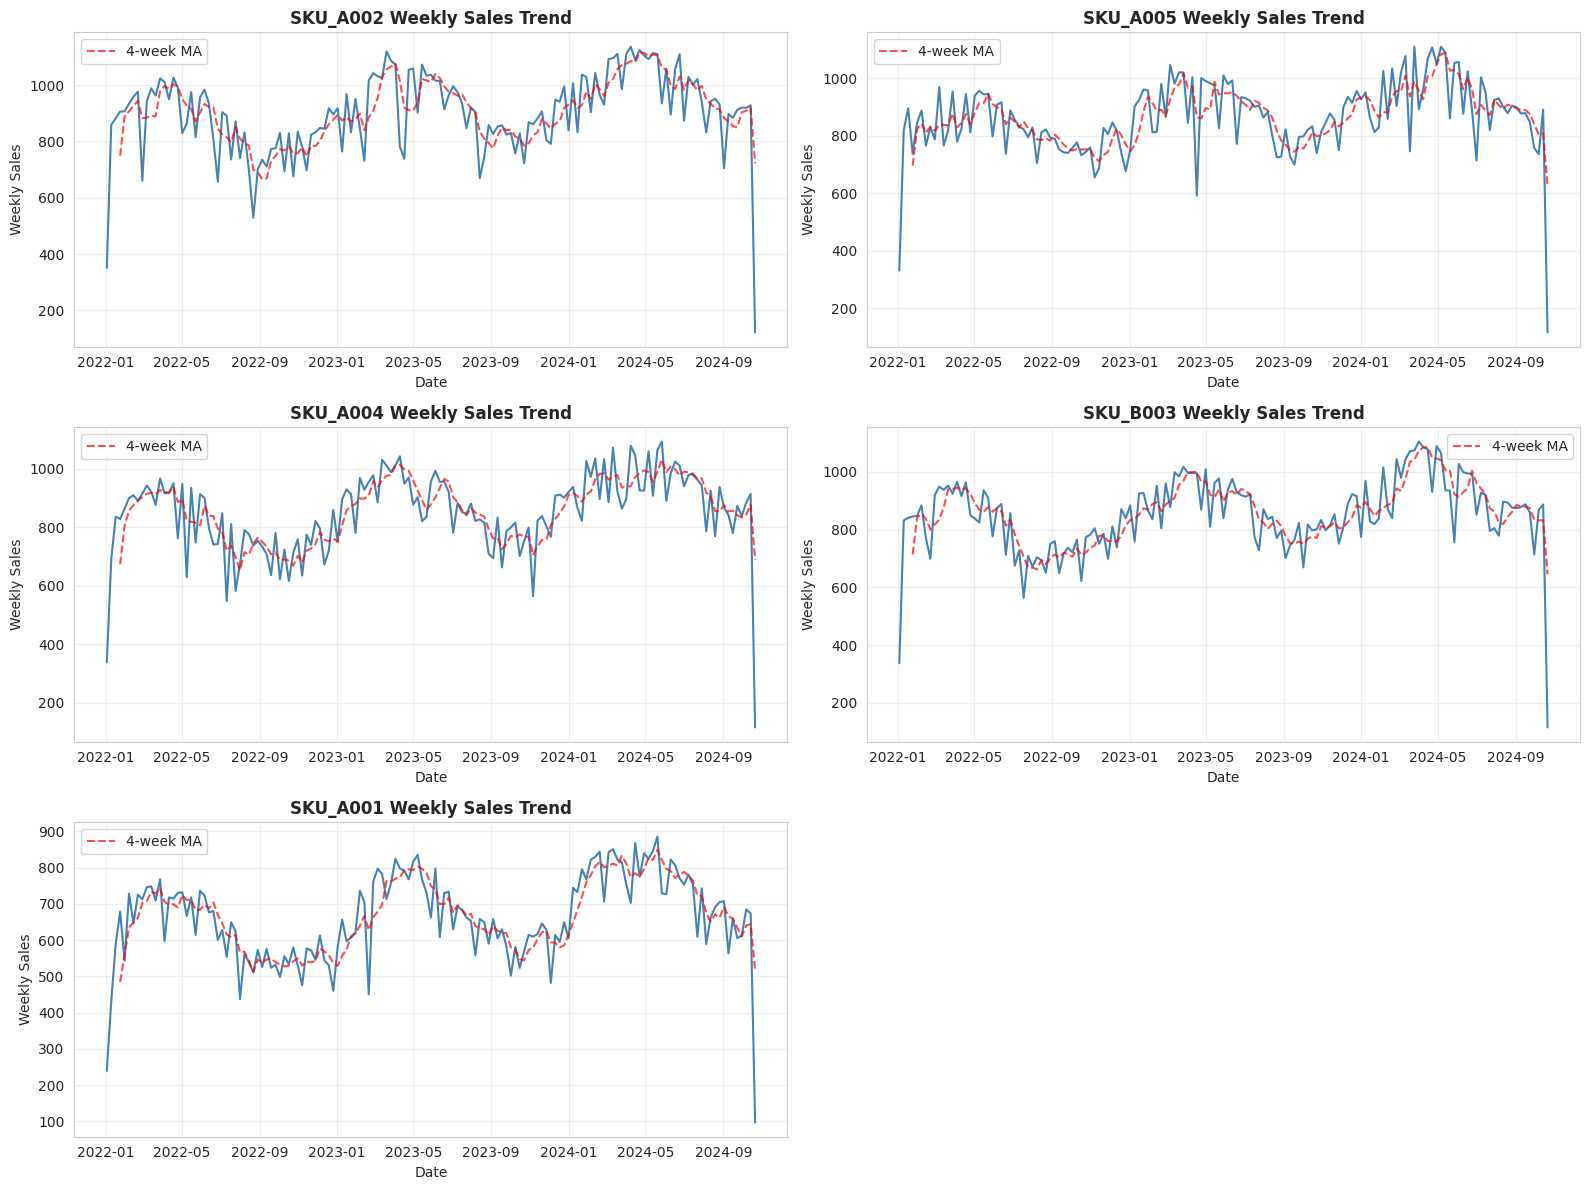

In [4]:
sku_total_sales = df_final.groupby('SKU')['Weekly_Sales'].sum().sort_values(ascending=False)
top_5_skus = sku_total_sales.head(5).index.tolist()

print(f'Top 5 SKUs: {top_5_skus}')
print('\Total Sales by SKU:')
display(sku_total_sales)

# Visualize top 5 SKUs
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, sku in enumerate(top_5_skus):
    sku_data = df_final[df_final['SKU'] == sku].sort_values('Week_Start')
    axes[idx].plot(sku_data['Week_Start'], sku_data['Weekly_Sales'],
                   linewidth=1.5, color='steelblue')
    axes[idx].set_title(f'{sku} Weekly Sales Trend', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Weekly Sales')
    axes[idx].grid(True, alpha=0.3)

    ma_4week = sku_data['Weekly_Sales'].rolling(window=4).mean()
    axes[idx].plot(sku_data['Week_Start'], ma_4week,
                   color='red', linestyle='--', alpha=0.7, label='4-week MA')
    axes[idx].legend()

axes[5].axis('off')
plt.tight_layout()
plt.show()

##  Section 5: LSTM Model Building\n
\n
**TASK 6:** Build an LSTM model for one SKU

In [5]:

# Select top performing SKU
selected_sku = top_5_skus[0]
sku_data = df_final[df_final['SKU'] == selected_sku].copy()
sku_data = sku_data.sort_values('Week_Start').reset_index(drop=True)

print(f'Selected SKU: {selected_sku}')
print(f'Total weeks of data: {len(sku_data)}')

# Prepare data
sales_values = sku_data['Weekly_Sales'].values.reshape(-1, 1)

# Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
sales_scaled = scaler.fit_transform(sales_values)

print(f'Original sales range: [{sales_values.min():.2f}, {sales_values.max():.2f}]')
print(f'Scaled sales range: [{sales_scaled.min():.4f}, {sales_scaled.max():.4f}]')

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

sequence_length = 12
X, y = create_sequences(sales_scaled, sequence_length)

print(f'\Sequence length (lookback): {sequence_length} weeks')
print(f'Total sequences: {len(X)}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Split data
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f'\Data split:')
print(f'Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)')

Selected SKU: SKU_A002
Total weeks of data: 147
Original sales range: [121.98, 1136.47]
Scaled sales range: [0.0000, 1.0000]
\Sequence length (lookback): 12 weeks
Total sequences: 135
X shape: (135, 12, 1)
y shape: (135, 1)
\Data split:
Training: 94 samples (69.6%)
Validation: 20 samples (14.8%)
Test: 21 samples (15.6%)


In [6]:
# Build LSTM model
model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print('Model Architecture:')
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Section 6: Model Training\n
\n
**TASK 7:** Train, validate and test time-series forecasting

In [7]:


# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Train model
print('Training LSTM model...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print('\✓ Training completed!')

Training LSTM model...
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.3614 - mae: 0.5753 - val_loss: 0.0812 - val_mae: 0.2757 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0435 - mae: 0.1731 - val_loss: 0.0193 - val_mae: 0.1180 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0469 - mae: 0.1687 - val_loss: 0.0265 - val_mae: 0.1488 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0263 - mae: 0.1315 - val_loss: 0.0454 - val_mae: 0.2006 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0273 - mae: 0.1370 - val_loss: 0.0156 - val_mae: 0.1128 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0164 - mae: 0.0987 - val_loss: 0.0064 - val_mae: 0.0717 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0224 - mae: 0.1159 - val_loss: 0.0154 - val_mae: 0.1121 - learning_rate: 0.0

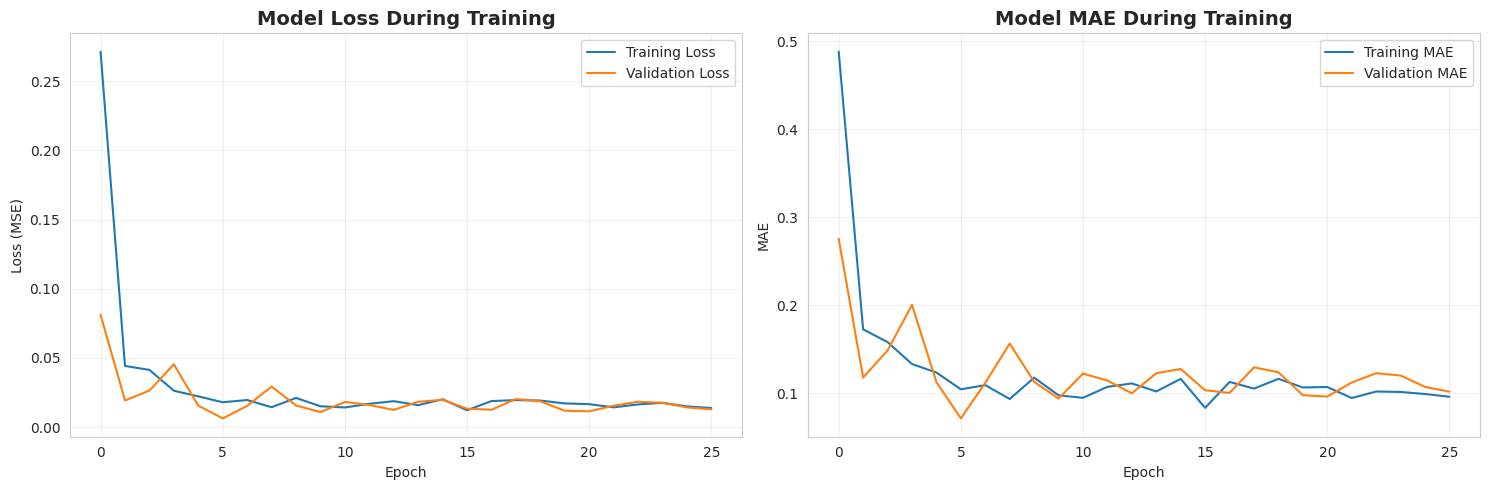

In [8]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss During Training', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Model MAE During Training', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📈 Section 7: Model Evaluation\n
\n
**TASK 8:** Evaluate with RMSE and MAPE

In [10]:


def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    mse = mean_squared_error(actual, predicted)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'MSE': mse}

# Make predictions
train_pred_scaled = model.predict(X_train, verbose=0)
val_pred_scaled = model.predict(X_val, verbose=0)
test_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform
train_pred = scaler.inverse_transform(train_pred_scaled)
val_pred = scaler.inverse_transform(val_pred_scaled)
test_pred = scaler.inverse_transform(test_pred_scaled)

train_actual = scaler.inverse_transform(y_train)
val_actual = scaler.inverse_transform(y_val)
test_actual = scaler.inverse_transform(y_test)

# Calculate metrics
train_metrics = calculate_metrics(train_actual, train_pred)
val_metrics = calculate_metrics(val_actual, val_pred)
test_metrics = calculate_metrics(test_actual, test_pred)

# Display results

for metric, value in train_metrics.items():
    unit = '%' if metric == 'MAPE' else ''
    print(f'{metric:15s}: {value:8.2f}{unit}')


for metric, value in val_metrics.items():
    unit = '%' if metric == 'MAPE' else ''
    print(f'{metric:15s}: {value:8.2f}{unit}')


for metric, value in test_metrics.items():
    unit = '%' if metric == 'MAPE' else ''
    print(f'{metric:15s}: {value:8.2f}{unit}')

# Performance interpretation
if test_metrics['MAPE'] < 10:
    performance = 'Excellent'
elif test_metrics['MAPE'] < 20:
    performance = 'Good'
elif test_metrics['MAPE'] < 30:
    performance = 'Acceptable'
else:
    performance = 'Needs Improvement'

print(f'\Model Performance: {performance}')

RMSE           :   113.93
MAE            :    87.71
MAPE           :    11.01%
MSE            : 12979.58
RMSE           :    80.86
MAE            :    72.72
MAPE           :     7.02%
MSE            :  6539.14
RMSE           :   205.06
MAE            :   109.83
MAPE           :    40.10%
MSE            : 42051.63
\Model Performance: Needs Improvement


## 🔄 Section 8: Batch Processing\n
\n
**TASK 9:** Forecast for multiple SKUs using batch processing

In [ ]:


def forecast_sku(df, sku, sequence_length=12):
    sku_data = df[df['SKU'] == sku].copy()
    sku_data = sku_data.sort_values('Week_Start').reset_index(drop=True)

    sales_values = sku_data['Weekly_Sales'].values.reshape(-1, 1)

    scaler_sku = MinMaxScaler(feature_range=(0, 1))
    sales_scaled = scaler_sku.fit_transform(sales_values)

    X_sku, y_sku = create_sequences(sales_scaled, sequence_length)

    train_size_sku = int(len(X_sku) * 0.8)
    X_train_sku = X_sku[:train_size_sku]
    y_train_sku = y_sku[:train_size_sku]
    X_test_sku = X_sku[train_size_sku:]
    y_test_sku = y_sku[train_size_sku:]

    # Build and train model
    model_sku = Sequential([
        LSTM(units=64, return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        LSTM(units=32, return_sequences=False),
        Dropout(0.2),
        Dense(units=16, activation='relu'),
        Dense(units=1)
    ])

    model_sku.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )

    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True, verbose=0)

    model_sku.fit(
        X_train_sku, y_train_sku,
        epochs=50,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    test_pred_scaled = model_sku.predict(X_test_sku, verbose=0)
    test_pred = scaler_sku.inverse_transform(test_pred_scaled)
    test_actual = scaler_sku.inverse_transform(y_test_sku)

    metrics = calculate_metrics(test_actual, test_pred)

    return {
        'predictions': test_pred,
        'actuals': test_actual,
        'metrics': metrics,
        'dates': sku_data['Week_Start'].values[train_size_sku + sequence_length:]
    }

# Process top 5 SKUs
batch_results = {}
print(f'Processing {len(top_5_skus)} SKUs...')

for sku in top_5_skus:
    print(f'Processing {sku}...')
    result = forecast_sku(df_final, sku, sequence_length=12)
    batch_results[sku] = result
    print(f'  ✓ RMSE: {result["metrics"]["RMSE"]:.2f}, MAPE: {result["metrics"]["MAPE"]:.2f}%')

# Summary
summary_data = []
for sku, result in batch_results.items():
    summary_data.append({
        'SKU': sku,
        'RMSE': result['metrics']['RMSE'],
        'MAE': result['metrics']['MAE'],
        'MAPE': result['metrics']['MAPE']
    })

summary_df = pd.DataFrame(summary_data).sort_values('MAPE')


display(summary_df)
print(f'\Average MAPE: {summary_df["MAPE"].mean():.2f}%')

## 📊 Section 9: Visualization\n
\n
**TASK 10:** Visualize predictions vs actuals over time

In [ ]:


fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, sku in enumerate(top_5_skus):
    result = batch_results[sku]
    dates = result['dates']
    actuals = result['actuals'].flatten()
    predictions = result['predictions'].flatten()

    axes[idx].plot(dates, actuals, label='Actual', color='blue', linewidth=2, marker='o', markersize=3)
    axes[idx].plot(dates, predictions, label='Predicted', color='red', linewidth=2,
                   linestyle='--', marker='s', markersize=3)
    axes[idx].set_title(f\"{sku} - MAPE: {result['metrics']['MAPE']:.2f}%\",
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Weekly Sales')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

axes[5].axis('off')
plt.suptitle('LSTM Forecasting: Predictions vs Actuals for Top 5 SKUs',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 🎯 Section 10: Project Summary

In [ ]:


print(f'''
✓ All 10 tasks completed successfully!

Key Results:
- Dataset: {len(skus)} SKUs analyzed
- Time period: {df_final['Week_Start'].min().date()} to {df_final['Week_Start'].max().date()}
- Model architecture: 2-layer LSTM (64→32 units)
- Sequence length: {sequence_length} weeks
- Average MAPE across top 5 SKUs: {summary_df['MAPE'].mean():.2f}%
- Best performing SKU: {summary_df.iloc[0]['SKU']} (MAPE: {summary_df.iloc[0]['MAPE']:.2f}%)

Next Steps:
- Fine-tune hyperparameters for better accuracy
- Add external features (holidays, promotions, weather)
- Implement ensemble methods
- Deploy to production environment
- Set up automated retraining pipeline
''')


# Task
Load the CSV file "/content/Productlevel_Sales_Transactions_Dataset_Weekly.csv" into a dataframe and prepare the data for time series analysis by transforming it to a long format with 'Week' and 'Sales' columns, converting 'Week' to a time index, and handling any missing values. Then, continue with the remaining steps in the notebook, including preprocessing, EDA, model building, training, evaluation, batch processing, and visualization.

## Data transformation

### Subtask:
Melt the DataFrame from wide format to long format, creating a 'Week' and 'Sales' column.


**Reasoning**:
The first step is to melt the raw data from wide to long format using the specified columns and then display the head of the resulting DataFrame.



In [ ]:
weekly_cols = [col for col in df_raw.columns if col.startswith('Wk')]
id_cols = ['Scode', 'Pcode', 'Price']

df_melted = pd.melt(df_raw,
                    id_vars=id_cols,
                    value_vars=weekly_cols,
                    var_name='Week',
                    value_name='Sales')

print(f'Melted DataFrame Shape: {df_melted.shape}')
print('\nMelted DataFrame Head:')
display(df_melted.head())